# **FUNDAMENTOS DE APRENDIZAJE POR REFUERZO**
# **Redes Neuronales Artificiales**

## **Librerias**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from time import time
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'pandas'

# **Modelo de red neuronal aplicado a regresión**

## Cargar Dataset

In [43]:
dataset = pd.read_csv(filepath_or_buffer="https://raw.githubusercontent.com/cdavid2804/test-1/main/Housing_Price.csv")
ocean_proximity = dataset.pop('ocean_proximity')
print(np.shape(dataset))
dataset.sample(10)

(20640, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
19743,-122.20,40.26,15.0,2102.0,358.0,957.0,371.0,3.1908,137900.0
16834,-122.55,37.59,31.0,1331.0,245.0,598.0,225.0,4.1827,345500.0
19258,-122.73,38.46,14.0,2324.0,754.0,1026.0,677.0,1.7220,150000.0
14438,-117.24,32.80,19.0,1863.0,497.0,868.0,503.0,2.2880,210000.0
19971,-119.11,36.21,10.0,1972.0,455.0,1469.0,442.0,1.5407,58400.0
391,-122.30,37.90,15.0,5083.0,1212.0,2420.0,1146.0,4.5824,256100.0
5356,-118.39,34.05,35.0,2458.0,576.0,1047.0,554.0,4.0283,412500.0
2390,-119.46,36.91,12.0,2980.0,495.0,1184.0,429.0,3.9141,123900.0
9265,-119.81,36.92,14.0,4795.0,710.0,2047.0,640.0,4.6650,121300.0
851,-122.03,37.60,24.0,2077.0,383.0,1488.0,389.0,4.5721,214700.0


## Procesamiento de los datos

In [44]:
dataset = dataset.dropna()
print(np.shape(dataset))
X = dataset[['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']]
y = dataset['median_house_value']
X = X.values
y = y.values

(20433, 9)


### Normalización del conjunto de datos

In [45]:
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
y_mean = np.mean(y, axis=0)
y_std = np.std(y, axis=0)

In [46]:
X_norm = (X - X_mean) / X_std
y_norm = (y - y_mean) / y_std

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, test_size=0.1)
print(f"Training data: {X_train.shape[0]}")
print(f"Test data: {X_test.shape[0]}")

Training data: 18389
Test data: 2044


## **Construcción del Modelo**
1. Capa de entrada (input layer):
  - Recibe los datos de entrada (por ejemplo, píxeles de una imagen o valores de sensores).
2. Capas ocultas (hidden layers):
  - Procesan la información mediante operaciones matemáticas (producto punto, funciones de activación, etc.).
  - Cuantas más capas tenga, más compleja puede ser la función que la red aprende (esto se llama profundidad).

3. Capa de salida (output layer):
  - Genera el resultado final (por ejemplo, la clase de una imagen o un valor numérico).

In [48]:
num_inputs = X.shape[1]
num_outputs = 1
print(f"Inputs: {num_inputs}")
print(f"Num Outputs: {num_outputs}")

Inputs: 8
Num Outputs: 1


### Modelo Secuencial
La creación de un modelo secuencial consiste en definir una red neuronal, añadiendo capa por capa, en orden lineal. Es el tipo de modelo más simple y directo. Se utiliza la API `tf.keras.Sequential()`

In [49]:
np.random.seed(42)
model_sec = tf.keras.Sequential()
model_sec.add(tf.keras.layers.Input(shape=(num_inputs,)))
model_sec.add(tf.keras.layers.Dense(32, activation='relu')) #primera capa oculta (32 neuronas, funcion de activacion RELU)
model_sec.add(tf.keras.layers.Dense(32, activation='relu')) #segunda capa oculta (32 neuronas, funcion de activacion RELU)
model_sec.add(tf.keras.layers.Dense(num_outputs, activation='linear')) #capa de salida

alpha = 0.01 # taza de aprendizaje
model_sec.compile(loss=tf.keras.losses.mse, optimizer=tf.keras.optimizers.Adam(alpha), metrics=['mse'])
model_sec.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,377 (5.38 KB)

 Trainable params: 1,377 (5.38 KB)

 Non-trainable params: 0 (0.00 B)

### Modelo Funcional
La creación de un modelo funcional define una red neuronal capa por capa, en orden lineal, donde la salida de una capa es la entrada de la siguiente.

In [50]:
input = tf.keras.layers.Input(shape=(num_inputs,)) #capa de entrada
x = tf.keras.layers.Dense(32, activation='relu')(input) #primera capa oculta
x = tf.keras.layers.Dense(32, activation='relu')(x) #segunda capa oculta
output = tf.keras.layers.Dense(num_outputs, activation='linear')(x) #capa de salida
model_func = tf.keras.Model(inputs=input, outputs=output)

alpha = 0.01
model_func.compile(loss=tf.keras.losses.mse, optimizer=tf.keras.optimizers.Adam(alpha), metrics=['mse'])
model_func.summary()


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,377 (5.38 KB)

 Trainable params: 1,377 (5.38 KB)

 Non-trainable params: 0 (0.00 B)

## **Entrenamiento del modelo**
Utilizar `name_model.fit` para entrenar y ajustar los parámetros de su modelo y minimizar la pérdida.

In [51]:
model_sec.fit(X_train, y_train, epochs=100, verbose=1)

Epoch 1/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3222 - mse: 0.3222
Epoch 2/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2652 - mse: 0.2652
Epoch 3/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2555 - mse: 0.2555
Epoch 4/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2466 - mse: 0.2466
Epoch 5/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2427 - mse: 0.2427
Epoch 6/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2406 - mse: 0.2406
Epoch 7/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2373 - mse: 0.2373
Epoch 8/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2294 - mse: 0.2294
Epoch 9/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2291 - mse: 0.2291
Epoch 10/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2298 - mse: 0.2298
Epoch 11/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2248 - mse: 0.2248
Epoch 12/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2228 - mse: 0.2228
Epoch 13/100


### Evaluación del modelo
El método `name_model.evaluate` verifica el rendimiento del modelo, generalmente en un conjunto de validación o en un conjunto de prueba.

In [52]:
model_sec.evaluate(X_test, y_test, verbose=2)

64/64 - 1s - 12ms/step - loss: 0.2079 - mse: 0.2079


[0.2078750878572464, 0.2078750878572464]

### Predecciones del modelo
Se usa `name_model.predict()` para hacer predicciones

In [53]:
y_pred = model_sec.predict(X_test, verbose=0)
y_pred = y_pred.T[0]
y_pred = y_pred * y_std + y_mean

print(f"Prediction: {y_pred}")

Prediction: [143301.65559764 133194.32174851 280552.91633448 ... 225335.86234124
 139624.7021369  469259.41900984]


# **Model de red neuronal aplicado a clasificación de imágenes**
# **Dataset: MNIST**

La base de datos MNIST de dígitos manuscritos cuenta con un conjunto de entrenamiento de 60 000 ejemplos y un conjunto de prueba de 10 000.

https://www.kaggle.com/datasets/hojjatk/mnist-dataset

In [73]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import random
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
from time import time

## Dataset

In [74]:
# the data, split between train and test sets
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
print(f"Datos de entrenamiento: {X_train.shape[0]}")
print(f"Datos de prueba: {X_test.shape[0]}")

Datos de entrenamiento: 60000
Datos de prueba: 10000


In [75]:
input_shape = (X_train.shape[1] , X_train.shape[2], 1)
print(f"Dimensiones datos entrada: {input_shape}")

Dimensiones datos entrada: (28, 28, 1)


In [76]:
X_train.shape

(60000, 28, 28)

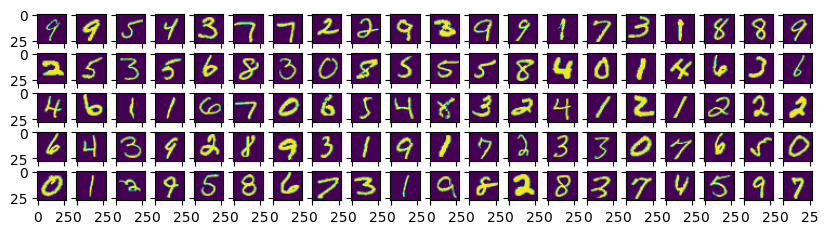

In [77]:
nrows = 5
ncolumns = 20
fig = plt.figure(figsize=(10., 10.))
grid = ImageGrid(fig, 111,  # similar to subplot(111)
                 nrows_ncols=(nrows, ncolumns),
                 axes_pad=0.1,  # pad between axes in inch.
                 )

x_train_list = list(X_train[:,:,:])
random.shuffle(x_train_list)
for ax, im in zip(grid, x_train_list[:nrows*ncolumns]):
    # Iterating over the grid returns the Axes.
    ax.imshow(im)
plt.show()

## **Preprocesamiento los datos**

In [78]:
num_classes = 10
input_shape = (28, 28 , 1)
X_train = X_train / 255
X_test = X_test / 255

### Redimensionar datos de entrada

In [79]:
num_inputs = X_train.shape[1]*X_train.shape[2]
X_train = X_train.reshape(X_train.shape[0], num_inputs)
X_test = X_test.reshape(X_test.shape[0], num_inputs)
print(f"Inputs: {num_inputs}")

Inputs: 784


## **Construcción del modelo**

- La función de activación de la capa de salida es: softmax
- La función de perdida tiene que ser sparse_categorical_crossentropy
- La metrica es: accuracy

In [80]:
np.random.seed(42)
input = tf.keras.layers.Input(shape=(num_inputs,)) #capa de entrada
x = tf.keras.layers.Dense(16, activation='relu')(input) #primera capa oculta
x = tf.keras.layers.Dense(16, activation='relu')(x) #segunda capa oculta
output = tf.keras.layers.Dense(num_classes, activation='softmax')(x) #capa de salida
model = tf.keras.Model(inputs=input, outputs=output)

alpha = 0.01
model.compile(loss=tf.keras.losses.sparse_categorical_crossentropy, optimizer=tf.keras.optimizers.Adam(alpha), metrics=['accuracy'])
model.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,002 (50.79 KB)

 Trainable params: 13,002 (50.79 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento del modelo

In [81]:
model.fit(X_train, y_train, epochs=20, verbose=1)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8925 - loss: 0.3586
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9255 - loss: 0.2609
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9317 - loss: 0.2406
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9326 - loss: 0.2357
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9349 - loss: 0.2281
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9345 - loss: 0.2281
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9384 - loss: 0.2221
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9384 - loss: 0.2188
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9403 - loss: 0.2143
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9394 - loss: 0.2138
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9402 - loss: 0.2109
Epoch 12/20
1875/1875 ━━━━━━━━

### Predicciones del modelo

In [82]:
def plot_label_dist(predictions_array, true_label):
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)
  #true_label = np.argmax(true_label)
  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

def plot_image_and_label(predictions_array, true_label, img, class_names):
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  img = np.reshape(img, (28, 28)) # drop any trailing dimension of size 1
  plt.imshow(img, cmap=plt.cm.binary)
  predicted_label = np.argmax(predictions_array)
  #true_label = np.argmax(true_label)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'
  plt.xlabel("truth={}, pred={}, score={:2.0f}%".format(
      class_names[true_label],
      class_names[predicted_label],
      100*np.max(predictions_array)),
      color=color)

def find_interesting_test_images(predictions, test_labels):
  # We select the first 9 images plus 6 error images
  pred = np.argmax(predictions, axis=1)
  #test_labels = np.argmax(test_labels, axis=1)
  errors = np.where(pred != test_labels)[0]
  print(errors.shape)
  ndx1 = range(9)
  ndx2 = errors[:6]
  ndx = np.concatenate((ndx1, ndx2))
  return ndx

def plot_interesting_test_results(test_images, test_labels, predictions,
                                  class_names, ndx):
  # Plot some test images, their predicted label, and the true label
  # Color correct predictions in blue, incorrect predictions in red
  num_rows = 5
  num_cols = 3
  num_images = num_rows*num_cols
  plt.figure(figsize=(2*2*num_cols, 2*num_rows))
  for i in range(num_images):
    n = ndx[i]
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image_and_label(predictions[n], test_labels[n], test_images[n],
                         class_names)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_label_dist(predictions[n], test_labels[n])
  plt.show()

In [83]:
y_pred = model.predict(X_test, verbose=0)
y_pred_num = np.argmax(y_pred, axis=1)

print(f"Real: {y_test[0:15]}")
print(f"Prediction: {y_pred_num[0:15]}")


Real: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1]
Prediction: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1]


(656,)


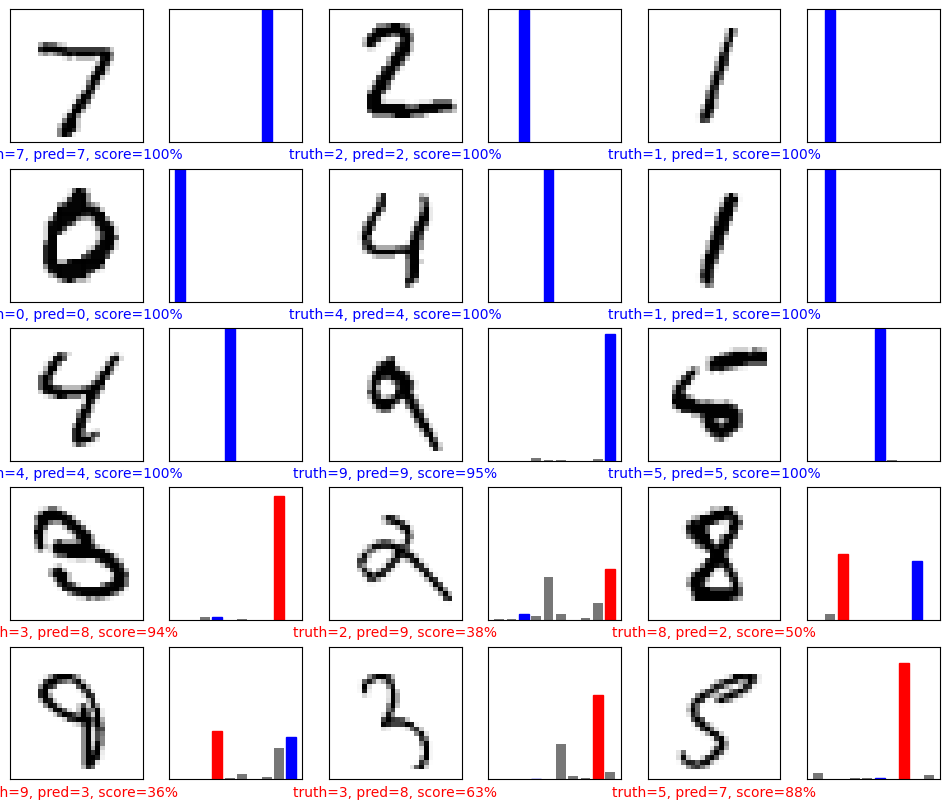

In [84]:
class_names = [str(x) for x in range(10)]
ndx = find_interesting_test_images(y_pred, y_test)
plot_interesting_test_results(X_test, y_test, y_pred, class_names, ndx)